# Brazilian E-Commerce Public Dataset by Olist Analysis

## Loading & cleaning datasets

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.linear_model import LinearRegression
from datetime import timedelta


In [3]:
path = './row data/'

orders = pd.read_csv(path + 'orders.csv', parse_dates = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']);
customers = pd.read_csv(path + 'customers.csv');
geolocation = pd.read_csv(path + 'geolocation.csv');
order_items = pd.read_csv(path + 'order_items.csv', parse_dates=['shipping_limit_date']);
order_payments = pd.read_csv(path + 'order_payments.csv');
order_reviews = pd.read_csv(path + 'order_reviews.csv', parse_dates=['review_creation_date', 'review_answer_timestamp']);
products = pd.read_csv(path + 'products.csv');
sellers = pd.read_csv(path + 'sellers.csv');
product_category_name_translation = pd.read_csv(path + 'product_category_name_translation.csv');


### orders table

In [4]:
orders.info()
# there are some missing values in order_delivered_carrier_date, order_delivered_customer_date, order_estimated_delivery_date 
# we can not delete this order

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 6.1 MB


In [5]:
orders['order_id'].duplicated().sum()
# there is no dupplicate

np.int64(0)

In [6]:
orders['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

### customers table

In [7]:
customers['customer_zip_code_prefix'] = customers['customer_zip_code_prefix'].astype(str)
customers.info()
# there is no missing values

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  str  
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: str(5)
memory usage: 3.8 MB


In [8]:
customers['customer_id'].duplicated().sum()
# there is no dupplicate

np.int64(0)

### geolocation table

In [9]:
geolocation['geolocation_zip_code_prefix'] = geolocation['geolocation_zip_code_prefix'].astype(str) 
geolocation.info()
# there is no missing values

<class 'pandas.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  str    
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  str    
 4   geolocation_state            1000163 non-null  str    
dtypes: float64(2), str(3)
memory usage: 38.2 MB


In [10]:
print(geolocation.duplicated().sum())
# there are 261831 dupplicated rows
geolocation.drop_duplicates(inplace=True)
# dupplicated rows have been removed

261831


### order_items table

In [11]:
order_items['order_item_id'] = order_items['order_item_id'].astype(str)
order_items.info()
# there is no missing values

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  str           
 1   order_item_id        112650 non-null  str           
 2   product_id           112650 non-null  str           
 3   seller_id            112650 non-null  str           
 4   shipping_limit_date  112650 non-null  datetime64[us]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[us](1), float64(2), str(4)
memory usage: 6.0 MB


In [12]:
order_items.duplicated().sum()
# there is no dupplicate

np.int64(0)

### order_payments table

In [13]:
order_payments.info()

<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  str    
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  str    
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 4.0 MB


In [14]:
order_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [15]:
order_payments.duplicated().sum()
# there is no duplicated rows

np.int64(0)

### order_reviews table

In [16]:
order_reviews.info()
# there are some missing values in review_comment_title & review_comment_message which is something normal and we can keep it.

<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  str           
 1   order_id                 99224 non-null  str           
 2   review_score             99224 non-null  int64         
 3   review_comment_title     11568 non-null  str           
 4   review_comment_message   40977 non-null  str           
 5   review_creation_date     99224 non-null  datetime64[us]
 6   review_answer_timestamp  99224 non-null  datetime64[us]
dtypes: datetime64[us](2), int64(1), str(4)
memory usage: 5.3 MB


In [17]:
print(order_reviews['review_id'].duplicated().sum())
# There is 814 duplicated rows

order_reviews.drop_duplicates(subset=['review_id'], inplace=True)

814


### products table

In [18]:
products.info()
# there are some missing data in product_category_name, product_name_lenght, product_description_lenght, product_photos_qty, product_weight_g, product_length_cm, product_height_cm and product_width_cm
# we will fix the missing values in product_category_name only and other columns it is not important.

<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 2.3 MB


In [19]:
products['product_category_name'] = products['product_category_name'].fillna('Unknown')

In [20]:
products['product_id'].duplicated().sum()
# there is no duplicated rows

np.int64(0)

In [21]:
products['product_category_name'].unique()

<StringArray>
[                                    'perfumaria',
                                          'artes',
                                  'esporte_lazer',
                                          'bebes',
                          'utilidades_domesticas',
                          'instrumentos_musicais',
                                     'cool_stuff',
                               'moveis_decoracao',
                               'eletrodomesticos',
                                     'brinquedos',
                                'cama_mesa_banho',
               'construcao_ferramentas_seguranca',
                         'informatica_acessorios',
                                   'beleza_saude',
                               'malas_acessorios',
                             'ferramentas_jardim',
                              'moveis_escritorio',
                                     'automotivo',
                                    'eletronicos',
                 

### sellers table

In [22]:
sellers['seller_zip_code_prefix'] = sellers['seller_zip_code_prefix'].astype(str)
sellers.info()
# there is no missing values

<class 'pandas.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   seller_id               3095 non-null   str  
 1   seller_zip_code_prefix  3095 non-null   str  
 2   seller_city             3095 non-null   str  
 3   seller_state            3095 non-null   str  
dtypes: str(4)
memory usage: 96.8 KB


In [23]:
sellers.duplicated().sum()
# there is no dupplicated rows

np.int64(0)

### product_category_name_translation

In [24]:
product_category_name_translation.info()
# there is no missing values

<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   product_category_name          71 non-null     str  
 1   product_category_name_english  71 non-null     str  
dtypes: str(2)
memory usage: 1.2 KB


## Sales & Revenue Analysis

### What is the Monthly Growth Trend?

In [25]:
df1 = pd.merge(orders, order_items, on='order_id', how='inner')
df1['order_purchase_timestamp'] = df1['order_purchase_timestamp'].dt.normalize()

temp = df1.groupby('order_purchase_timestamp')['price'].sum().reset_index()

fig = px.line(temp, x='order_purchase_timestamp', y='price', 
              title='Interactive Sales Revenue',
              labels={'order_purchase_timestamp': 'Date', 'price': 'Sales ($)'})

fig.show()

By analyzing the slope and peak density, we can categorize the growth into four distinct phases:

#### 1. The Dormant Phase (Late 2016 – Jan 2017)
The trend begins with negligible activity. 
* **Observations:** A minor "blip" occurs in October 2016, followed by a flatline. 
* **Conclusion:** This suggests the platform was likely in a **soft-launch phase** or experiencing significant early-stage friction.

#### 2. Consistent Upward Trajectory (Feb 2017 – Oct 2017)
Starting in February 2017, the data enters a linear upward trend.
* **Monthly Growth:** The baseline "floor" of sales rises steadily every month.
* **Volatility:** Day-to-day variance increases alongside volume, a standard indicator of scaling e-commerce.

#### 3. The "Black Friday" Breakout (Nov 2017)
The massive spike on **Nov 24, 2017 ($152.65k)** serves as the dataset's primary turning point.
* **Context:** This is almost certainly driven by Black Friday.
* **Significance:** Following this event, the "new normal" for sales never returns to pre-November levels. The spike acted as a **mass acquisition event** that permanently shifted the baseline higher.

#### 4. Mature Volatility (Dec 2017 – Aug 2018)
Post-spike, the trend stabilizes into a plateau at a significantly higher volume.
* **Stability:** Growth is less steep than in early 2017, but daily averages consistently maintain between **$20k and $50k**.
* **Peak Patterns:** A recurring **"sawtooth" pattern** is visible, suggesting established weekly cycles (e.g., specific shopping habits shifting between weekdays and weekends).

---

### Which Product Categories are the Revenue Drivers?

In [26]:
df2 = pd.merge(products, order_items, on="product_id", how="inner")
df3 = pd.merge(
    df2, product_category_name_translation, on="product_category_name", how="inner"
)

# 1. Grouping by category and calculating the necessary metrics
category_analysis = df3.groupby('product_category_name_english').agg(
    total_sales=('price', 'sum'),
    order_count=('order_id', 'nunique'),
    total_items=('order_item_id', 'count')
).reset_index()

# 2. Calculating Average Order Value (AOV)
# AOV is typically Total Revenue / Total Number of Unique Orders
category_analysis['aov'] = category_analysis['total_sales'] / category_analysis['order_count']

# 3. Sorting by total sales to see the top revenue drivers
category_analysis = category_analysis.sort_values(by='total_sales', ascending=False)

# Display the top 10 categories
print(category_analysis.head(10))

   product_category_name_english  total_sales  order_count  total_items  \
43                 health_beauty   1258681.34         8836         9670   
70                 watches_gifts   1205005.68         5624         5991   
7                 bed_bath_table   1036988.68         9417        11115   
65                sports_leisure    988048.97         7720         8641   
15         computers_accessories    911954.32         6689         7827   
39               furniture_decor    729762.49         6449         8334   
20                    cool_stuff    635290.85         3632         3796   
49                    housewares    632248.66         5884         6964   
5                           auto    592720.11         3897         4235   
42                  garden_tools    485256.46         3518         4347   

           aov  
43  142.449224  
70  214.261323  
7   110.118794  
65  127.985618  
15  136.336421  
39  113.159015  
20  174.914882  
49  107.452186  
5   152.096513  
42  

### What is the Customer Concentration?

In [27]:
df4 = pd.merge(customers, orders, on="customer_id", how="inner")
df5 = pd.merge(df4, order_items, on="order_id", how='inner')

# Group by unique customer and count unique orders
customer_orders = df5.groupby('customer_unique_id')['order_id'].nunique().reset_index()
customer_orders.columns = ['customer_unique_id', 'order_count']

# Identify repeat vs one-time customers
customer_orders['is_repeat'] = customer_orders['order_count'] > 1

# Calculate the number of Power Users
repeat_customer_count = customer_orders['is_repeat'].sum()
total_customers = len(customer_orders)
print(f"Repeat Customers: {repeat_customer_count} ({repeat_customer_count/total_customers:.2%})")

# Map the repeat status back to the original dataframe
df5 = df5.merge(customer_orders[['customer_unique_id', 'is_repeat']], on='customer_unique_id', how='left')

# Calculate total revenue per group
revenue_by_group = df5.groupby('is_repeat')['price'].sum()
total_revenue = revenue_by_group.sum()

# Calculate percentages
repeat_revenue_pct = (revenue_by_group[True] / total_revenue) * 100
one_time_revenue_pct = (revenue_by_group[False] / total_revenue) * 100

print(f"Percentage of Revenue from Repeat Customers: {repeat_revenue_pct:.2f}%")

Repeat Customers: 2913 (3.05%)
Percentage of Revenue from Repeat Customers: 5.62%


### How do Payment Methods impact Sales?

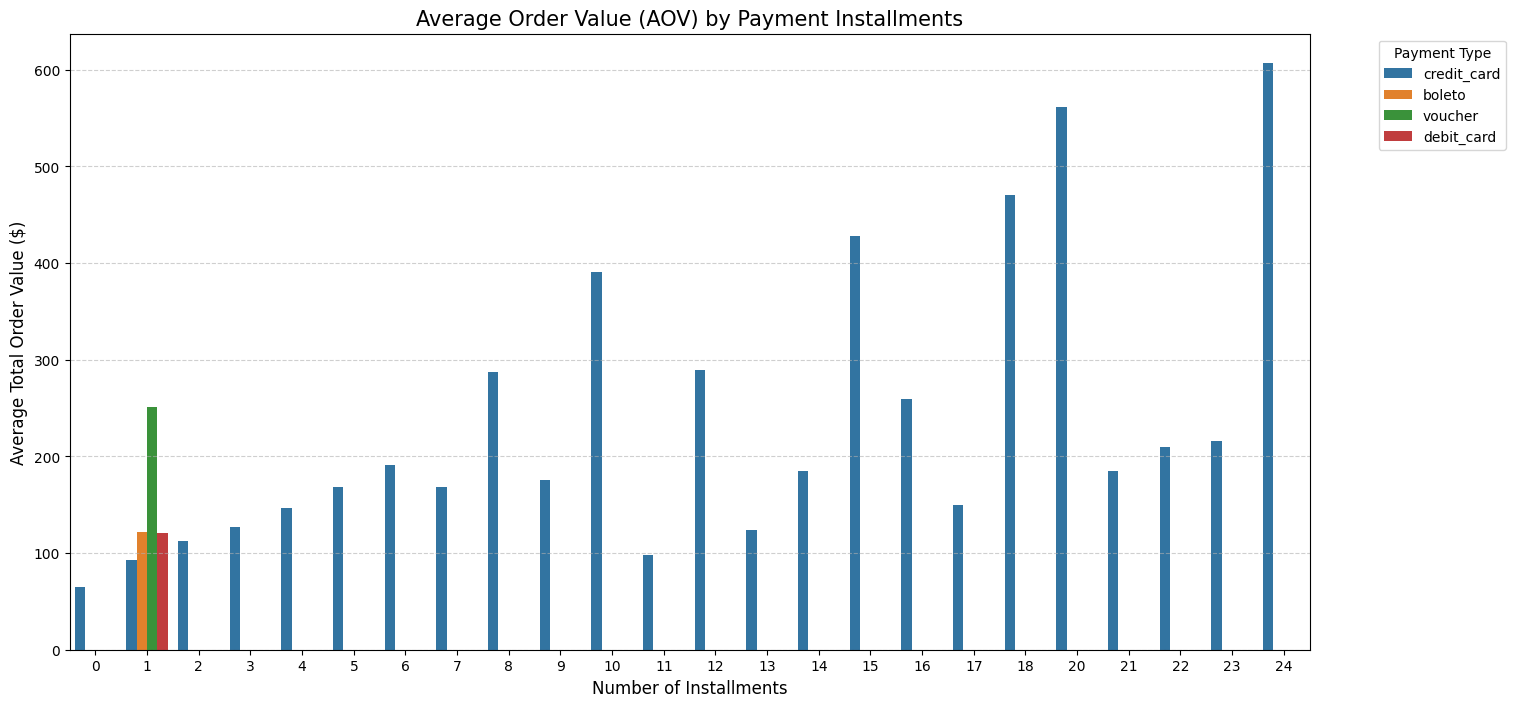

In [28]:
df6 = pd.merge(order_items, order_payments, on="order_id", how="inner")

order_totals = df6.groupby('order_id')['price'].sum().reset_index()
order_totals.rename(columns={'price': 'total_order_value'}, inplace=True)

order_payments = df6[['order_id', 'payment_type', 'payment_installments']].drop_duplicates()

df_aov = pd.merge(order_payments, order_totals, on='order_id')

plt.figure(figsize=(16, 8))
sns.barplot(
    data=df_aov, 
    x="payment_installments", 
    y="total_order_value", 
    hue="payment_type", 
    estimator='mean', 
    errorbar=None,   
    width=0.8  
)

plt.title("Average Order Value (AOV) by Payment Installments", fontsize=15)
plt.ylabel("Average Total Order Value ($)", fontsize=12)
plt.xlabel("Number of Installments", fontsize=12)
plt.legend(title="Payment Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

Payment methods act as a primary driver for high-value sales. While low-value orders are spread across all payment types (Boleto, Debit Card, Voucher, and Credit Card), high-value orders are almost exclusively processed via **Credit Card installments**. 

#### Do customers using credit_card with higher installments tend to have higher AOVs?

**Yes, the correlation is strong.** Here is the breakdown:

* **The Installment Growth Trend:** There is a clear, positive relationship between the number of installments and the AOV. Customers paying in **1 installment** have an AOV under **$100**, while those using **20 to 24 installments** have an AOV reaching between **$500 and $600**.
* **Threshold Behavior:** we can see "peaks" at common financial milestones (8, 10, 15, and 24 installments). This suggests that for orders totaling over **$300**, customers specifically seek out longer payment plans to make the purchase manageable.
* **Credit Card vs. Boleto:**
    * **Boleto:** At its only point of comparison (1 installment), Boleto actually has a higher AOV (approx. **$120**) than 1-installment credit cards (approx. **$90**). 
    * **Conclusion:** While a Boleto user might spend more on average than a single-payment credit card user, they cannot compete with the **Credit Card "Power User"** who uses 10+ installments to purchase much larger baskets of goods.

#### Business Insight
The data confirms that offering and promoting high-installment plans is essential for moving high-ticket items or encouraging larger "bundle" orders. Without the 20-24 installment option, those **$600+** average orders might not happen at all, as customers might not be willing or able to pay that total upfront via Boleto or Debit.

### What is the expected total sales volume for the next 90 days?

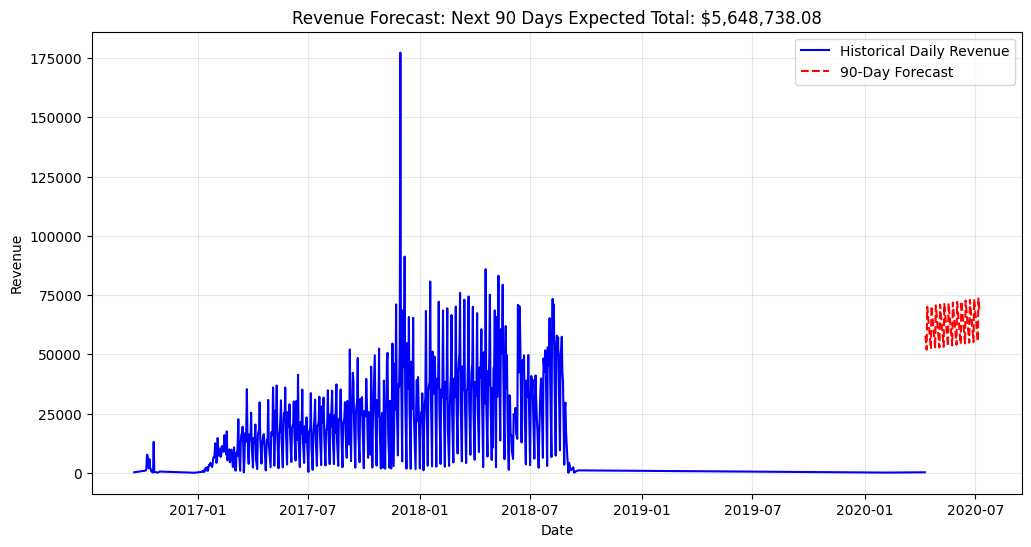

Total Expected Sales Volume (Revenue) for next 90 days: $5,648,738.08


In [29]:

# 1. Prepare the Data
# Ensure date is datetime and aggregate daily revenue
order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'])
daily_sales = order_items.groupby(order_items['shipping_limit_date'].dt.date)['price'].sum().reset_index()
daily_sales.columns = ['date', 'revenue']
daily_sales['date'] = pd.to_datetime(daily_sales['date'])

# 2. Feature Engineering for Scikit-Learn
# We use the ordinal date as a feature to capture the "trend"
daily_sales['ordinal_date'] = daily_sales['date'].map(pd.Timestamp.toordinal)

# Optional: Add day-of-week seasonality (0-6)
daily_sales['day_of_week'] = daily_sales['date'].dt.dayofweek

# Prepare X (features) and y (target)
X = daily_sales[['ordinal_date', 'day_of_week']]
y = daily_sales['revenue']

# 3. Train the Model
model = LinearRegression()
model.fit(X, y)

# 4. Predict for the Next 90 Days
last_date = daily_sales['date'].max()
future_dates = [last_date + timedelta(days=i) for i in range(1, 91)]
future_df = pd.DataFrame({'date': future_dates})
future_df['ordinal_date'] = future_df['date'].map(pd.Timestamp.toordinal)
future_df['day_of_week'] = future_df['date'].dt.dayofweek

# Generate forecast
forecast = model.predict(future_df[['ordinal_date', 'day_of_week']])
total_90_day_revenue = forecast.sum()

# 5. Visualization with Matplotlib
plt.figure(figsize=(12, 6))
plt.plot(daily_sales['date'], daily_sales['revenue'], label='Historical Daily Revenue', color='blue')
plt.plot(future_df['date'], forecast, label='90-Day Forecast', color='red', linestyle='--')
plt.title(f'Revenue Forecast: Next 90 Days Expected Total: ${total_90_day_revenue:,.2f}')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Total Expected Sales Volume (Revenue) for next 90 days: ${total_90_day_revenue:,.2f}")

## Logistics & Delivery Performance

### Which states have the highest rate of late deliveries?

Text(0.5, 1.0, 'Late Delivery Rate by Customer State')

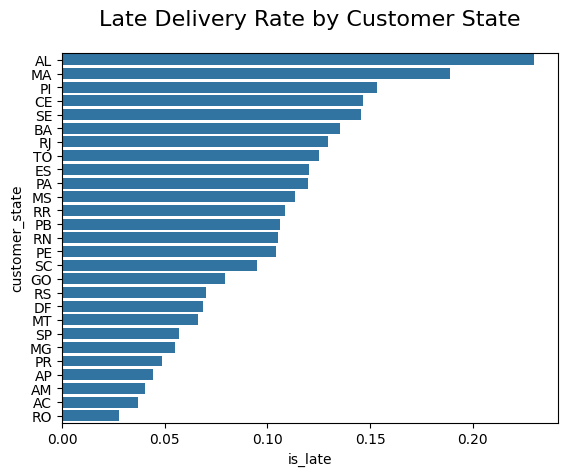

In [30]:
df7 = pd.merge(orders, customers, on='customer_id', how = 'inner')
# Calculate the time difference
df7['delivery_gap'] = df7['order_estimated_delivery_date'] - df7['order_delivered_customer_date']

# Convert to days (as a float) for easier analysis
df7['delivery_gap_days'] = df7['delivery_gap'].dt.total_seconds() / (24 * 3600)

# Define a late delivery (where delivered date > estimated date)
df7['is_late'] = df7['order_delivered_customer_date'] > df7['order_estimated_delivery_date']

# Calculate the rate per state
late_rate_by_state = df7.groupby('customer_state')['is_late'].mean().sort_values(ascending=False).reset_index()

sns.barplot(data=late_rate_by_state, y='customer_state', x='is_late')
plt.title('Late Delivery Rate by Customer State', fontsize=16, pad=20)

The chart shows a clear disparity in delivery performance across different regions. The states with the most significant challenges are:

1.  **AL (Alagoas):** This state has the highest rate of late deliveries by a significant margin, exceeding **20%** (approximately 23%).
2.  **MA (Maranhão):** Ranks second with a late delivery rate near **19%**.
3.  **PI (Piauí):** Follows with a rate of approximately **15%**.
4.  **CE (Ceará)** and **SE (Sergipe):** Both hover around the **14-15%** mark.

---

#### Key Observations from the Data
* **Regional Trends:** The top five states with the highest late rates (AL, MA, PI, CE, SE) are all located in the **Northeast region of Brazil**, suggesting potential logistical or infrastructural challenges in that specific area.
* **Best Performers:** Conversely, the state of **RO (Rondônia)** shows the best performance with the lowest late delivery rate, appearing to be below **3%**.
* **Average Performance:** A large cluster of states (including major hubs like SP, MG, and PR) maintains a relatively stable late rate between **5% and 7%**.

### What is the Lead Time by State?

In [31]:
df8 = pd.merge(orders, customers, on='customer_id', how='inner')
# Calculate Handling Time: Purchase to Carrier
df8['handling_time'] = (df8['order_delivered_carrier_date'] - df8['order_purchase_timestamp']).dt.days

# Calculate Transit Time: Carrier to Customer
df8['transit_time'] = (df8['order_delivered_customer_date'] - df8['order_delivered_carrier_date']).dt.days

# Group by state and calculate the mean for both metrics
lead_time_by_state = df8.groupby('customer_state')[['handling_time', 'transit_time']].mean().round()

# Display the results
print('time in days')
print(lead_time_by_state.sort_values(by='transit_time', ascending=False))

time in days
                handling_time  transit_time
customer_state                             
RR                        4.0          25.0
AP                        3.0          23.0
AM                        2.0          23.0
AL                        3.0          21.0
PA                        3.0          20.0
MA                        3.0          18.0
SE                        3.0          18.0
CE                        3.0          17.0
AC                        3.0          17.0
PB                        3.0          16.0
BA                        3.0          16.0
PI                        3.0          16.0
RO                        2.0          16.0
RN                        3.0          15.0
PE                        3.0          15.0
TO                        3.0          14.0
MT                        3.0          14.0
ES                        3.0          12.0
GO                        3.0          12.0
RS                        3.0          12.0
RJ                 

## Customer Satisfaction (Review Analysis)

### What is the Correlation between Delivery Delay and Review Score?

In [32]:
df8 = pd.merge(order_reviews, orders, on='order_id', how='inner')
# 1. Calculate the delay in days 
# (Positive values mean the delivery was late)
df8['delivery_delay'] = (df8['order_delivered_customer_date'] - df8['order_estimated_delivery_date']).dt.days

# 2. Calculate the Pearson correlation
correlation = df8[['delivery_delay', 'review_score']].corr().iloc[0, 1]

print(f"Correlation between Delivery Delay and Review Score: {correlation:.4f}")

Correlation between Delivery Delay and Review Score: -0.2673


The negative sign confirms a **negative relationship**. As the delivery delay increases (the package arrives later than expected), the review score tends to go down. This matches the logical expectation that late deliveries make customers unhappy.

A value of **-0.2673** is generally considered a **weak negative correlation**.

* **What this means:** While there is a connection between lateness and low scores, it isn't the *only* thing driving those scores. 
* **The "Why":** A weak correlation suggests that many customers might still give a 5-star rating even if a package is slightly late, or conversely, many 1-star ratings are being given for reasons completely unrelated to delivery (like a defective product or poor packaging).

## Seller Performance

### Who are the Top-Performing Sellers?

In [33]:
df9 = pd.merge(orders, order_items, on='order_id', how='inner')
df10 = pd.merge(df9, sellers, on='seller_id', how='inner')
df11 = pd.merge(df10, order_reviews, on='order_id', how='inner')
df12 = pd.merge(df10, products, on='product_id', how='inner')

# Merge df10 with reviews
seller_stats = df11.groupby('seller_id').agg(
    total_sales=('price', 'sum'),
    avg_review_score=('review_score', 'mean'),
    order_count=('order_id', 'count')
).reset_index()

# Filter for high satisfaction and sort by revenue
top_sellers = seller_stats[seller_stats['avg_review_score'] >= 4.0].sort_values(by='total_sales', ascending=False)

# Display the top 10
print(top_sellers.head(10))

                             seller_id  total_sales  avg_review_score  \
853   4869f7a5dfa277a7dca6462dcf3b52b2    227808.14          4.121291   
1009  53243585a1d6dc2643021fd1853d8905    220740.05          4.075980   
3017  fa1c13f2614d7b5c4749cbc52fecda94    192774.43          4.340206   
1555  7e93a43ef30c4f03f38b393420bc753a    176201.88          4.206490   
2636  da8622b14eb17ae2831f4ac5b9dab84a    157937.67          4.071195   
1500  7a67c85e85bb2ce8582c35f2203ad736    140810.60          4.233677   
1818  955fee9216a65b617aa5c0531780ce60    133818.81          4.050437   
839   46dc3b2cc0980fb8ec44634e21d2718e    126166.26          4.181308   
1194  620c87c171fb2a6dd6e8bb4dec959fc6    113355.90          4.209184   
1535  7d13fca15225358621be4086e1eb0964    113091.19          4.001742   

      order_count  
853          1146  
1009          408  
3017          582  
1555          339  
2636         1531  
1500         1164  
1818         1487  
839           535  
1194          78

### What is the Seller "Churn" Rate?

In [34]:
# Get the latest date in the data
last_date = df10['order_purchase_timestamp'].max()

# Calculate the last purchase date for every seller
seller_last_purchase = df10.groupby('seller_id')['order_purchase_timestamp'].max()

# Define the churn threshold (90 days)
churn_threshold = last_date - pd.Timedelta(days=90)

# Mark as churned if their last purchase was before the threshold
churned_sellers = seller_last_purchase[seller_last_purchase < churn_threshold]

total_sellers = df10['seller_id'].nunique()
num_churned = len(churned_sellers)

churn_rate = (num_churned / total_sellers) * 100
print(f"Seller Churn Rate: {churn_rate:.2f}%")

Seller Churn Rate: 41.87%


A **Seller Churn Rate of 41.87%** is a very significant figure that requires immediate attention. In simple terms, this means that nearly **4 out of every 10 sellers** who were previously active on the platform have stopped selling.

Here is a breakdown of what this specific percentage implies for the business:

---

#### 1. High Operational Instability
A churn rate of nearly 42% suggests a high level of "instability" in our seller base. While some churn is normal (natural business closures, seasonal sellers), a figure this high usually indicates a systemic issue. 
* **The Risk:** we are losing nearly half of our supply side. If this isn't balanced by an even higher acquisition rate, the marketplace will eventually collapse.

#### 2. Potential "Pain Points" in the Seller Journey
When churn hits this level, it’s rarely a coincidence. It often points to specific frustrations:
* **Profitability:** Sellers may find that after platform fees, shipping costs, and taxes, they aren't making enough money.
* **Competition:** Larger sellers might be "crowding out" smaller ones, making it impossible for new entries to get visibility.
* **Platform Friction:** Complex dashboard tools, slow payment cycles, or harsh penalty systems for late shipments might be driving sellers away.

#### 3. Impact on Customer Experience
* **Reduced Variety:** As sellers leave, the variety of products available to customers drops.
* **Price Increases:** With fewer sellers competing for the same customers, prices often rise, which can lead to "Buyer Churn" next.

#### 4. Financial "Burn"
It is almost always more expensive to acquire a new seller (marketing, onboarding, verification) than it is to keep an existing one. A 41.87% churn rate means the company is likely spending a massive amount of money just to "tread water"—replacing lost sellers rather than growing the total count.


### What is the Seller "Churn" Rate Segment by Volume?

In [35]:
# 2. Define the churn boundary (90 days ago)
last_date = df10['order_purchase_timestamp'].max()
churn_threshold = last_date - pd.Timedelta(days=90)

# 3. Aggregate data per seller
seller_stats = df10.groupby('seller_id').agg(
    total_items_sold=('order_item_id', 'count'),
    last_purchase=('order_purchase_timestamp', 'max')
)

# 4. Mark churned status
seller_stats['is_churned'] = seller_stats['last_purchase'] < churn_threshold

# 5. Create Volume Segments
def categorize_volume(vol):
    if vol <= 2: return '1. Low (1-2 items)'
    if vol <= 10: return '2. Mid (3-10 items)'
    if vol <= 50: return '3. High (11-50 items)'
    return '4. Top-Tier (50+ items)'

seller_stats['segment'] = seller_stats['total_items_sold'].apply(categorize_volume)

# 6. Calculate churn rate per segment
segment_summary = seller_stats.groupby('segment').agg(
    total_sellers=('is_churned', 'count'),
    churned_count=('is_churned', 'sum')
)
segment_summary['churn_rate_%'] = (segment_summary['churned_count'] / segment_summary['total_sellers']) * 100

print(segment_summary)

                         total_sellers  churned_count  churn_rate_%
segment                                                            
1. Low (1-2 items)                 837            542     64.755078
2. Mid (3-10 items)                947            457     48.257656
3. High (11-50 items)              849            239     28.150766
4. Top-Tier (50+ items)            462             58     12.554113


#### 1. The "Trial and Error" Filter (Low Segment)
The **64.75% churn rate** in the **Low (1-2 items)** category is expected. 
* **The Reality:** Most marketplaces have a "long tail" of casual sellers. These are people who likely listed a few items, sold them (or didn't), and then left. 
* **Business Impact:** This is high-volume but **low-risk**. While it looks bad on a spreadsheet, these sellers don't represent the core "engine" of our revenue.

#### 2. The Danger Zone (Mid to High Segments)
The churn rates of **48.25% (Mid)** and **28.15% (High)** are where the real concern lies.
* **The Reality:** These sellers have successfully moved between 3 and 50 items. They aren't casual; they are trying to build a business.
* **The Insight:** If nearly half of our "Mid" tier sellers are leaving, there is likely a barrier preventing them from scaling up to "High" or "Top-Tier." This could be due to increased shipping complexities or fees that kick in at higher volumes.

#### 3. The Core Strength (Top-Tier Segment)
The **12.55% churn rate** for **Top-Tier (50+ items)** is a very positive sign.
* **The Reality:** our most valuable sellers—the ones who provide the most inventory and reliability—are the most likely to stay. 
* **Business Impact:** This follows the **Pareto Principle (80/20 Rule)**. Since our "Top-Tier" represents our most stable group, the marketplace's fundamental foundation is still intact despite the high overall churn average.


---

#### Comparison of Impact
| Segment | Churn Rate | Strategic Priority |
| :--- | :--- | :--- |
| **Low** | 64.75% | **Ignore.** High churn here is a natural part of the "funnel." |
| **Mid/High** | 48% / 28% | **Investigate.** Find out why they aren't reaching the top tier. |
| **Top-Tier** | 12.55% | **Protect.** These 462 sellers are likely the lifeblood of the platform. |

#### Summary Conclusion
Our 41.87% total churn rate is "inflated" by casual sellers. The **"Real Churn"** affecting our core business is much lower (closer to 12-15%). 

However, we have a **"Growth Leak"** in the Mid-tier. If we can lower that 48% churn in the Mid-segment, those sellers will transition into the Top-Tier, leading to massive growth without we having to spend a single dollar on acquiring new sellers.

### What is the Seller "Churn" Rate Segment by Category?

In [36]:
# 1. Define churn boundary (using 90 days as before)
last_date = df12['order_purchase_timestamp'].max()
churn_threshold = last_date - pd.Timedelta(days=90)

# 2. Get the last sale date for every seller AND their main category
# We'll assign each seller to their most frequent category (mode)
seller_category = df12.groupby('seller_id')['product_category_name'].agg(lambda x: x.mode()[0])
seller_last_sale = df12.groupby('seller_id')['order_purchase_timestamp'].max()

# 3. Combine into a seller-level DataFrame
category_churn = pd.DataFrame({
    'category': seller_category,
    'last_sale': seller_last_sale
})

# 4. Mark Churn status
category_churn['is_churned'] = category_churn['last_sale'] < churn_threshold

# 5. Group by Category to see rates
category_summary = category_churn.groupby('category').agg(
    total_sellers=('is_churned', 'count'),
    churned_sellers=('is_churned', 'sum')
)

category_summary['churn_rate_%'] = (category_summary['churned_sellers'] / category_summary['total_sellers']) * 100

# 6. Filter for categories with at least 10 sellers for statistical significance
significant_categories = category_summary[category_summary['total_sellers'] >= 10].sort_values(by='churn_rate_%', ascending=False)

print(significant_categories.head(10))

                        total_sellers  churned_sellers  churn_rate_%
category                                                            
Unknown                           112              102     91.071429
artes                              10                7     70.000000
cool_stuff                         76               49     64.473684
consoles_games                     21               13     61.904762
livros_interesse_geral             38               22     57.894737
alimentos_bebidas                  19               11     57.894737
ferramentas_jardim                 96               54     56.250000
telefonia_fixa                     11                6     54.545455
instrumentos_musicais              35               18     51.428571
eletroportateis                    42               21     50.000000


This table shows that churn is not uniform across the marketplace. Instead, it is heavily concentrated in specific "problem niches." Having several categories with **churn rates over 50%** (some as high as 91%) suggests that certain product types are much harder to sell sustainably on our platform than others.

Here is the breakdown of what these specific results mean for the business:

---

#### 1. Data Quality Issues ("Unknown": 91.07%)
The highest churn is in the **"Unknown"** category. 
* **The Meaning:** Sellers whose products aren't properly categorized are almost guaranteed to leave.
* **Why:** If a product has no category, it likely doesn't appear in search results or filters. These 112 sellers probably saw zero traffic and left out of frustration. Improving our product onboarding flow could fix this immediately.

#### 2. High-Volatility / Niche Segments ("artes", "cool_stuff": 64-70%)
* **artes (Arts):** High churn here is common for "hobbyist" sellers who might sell a few unique pieces and then stop.
* **cool_stuff:** This is often a "catch-all" category for trend-based or novelty items. Sellers in this space often churn because trends die out quickly, or they are "one-hit wonders" who don't have a consistent supply chain.

#### 3. Tech & Competitive Pressures ("consoles_games", "telefonia_fixa": 54-61%)
These categories typically have very thin profit margins and high competition.
* **The Meaning:** Sellers in electronics often churn because they can't compete with the pricing of "Top-Tier" vendors. 
* **The Risk:** High churn in "Consoles & Games" is a warning sign; if these sellers are leaving, it usually means our platform's fees are higher than the razor-thin margins these products allow for.

#### 4. Logistics & Seasonality ("ferramentas_jardim", "eletroportateis": 50-56%)
* **ferramentas_jardim (Garden Tools):** This is highly **seasonal**. Much of this 56% churn might be sellers who only operate during spring and summer. They haven't necessarily "quit," they are just waiting for the next season.
* **eletroportateis (Small Appliances):** These items are often heavy or fragile. High churn here usually suggests a **shipping/logistics problem**—sellers might be getting hit with high freight costs or return shipping fees that eat their profits.

---

#### Summary of Strategic Priorities

| Priority | Category Segment | Recommended Action |
| :--- | :--- | :--- |
| **Urgent** | **Unknown** | Mandatory category selection during product upload to ensure visibility. |
| **Growth** | **Mid-Tier (Gardening/Appliances)** | Offer seasonal fee discounts or better shipping rates to keep them active year-round. |
| **Analysis** | **Consoles / Games** | Review our commission structure. It might be too high for low-margin electronics. |


By fixing the **"Unknown"** data issue alone, we could significantly lower our total average churn rate, as that 91% is currently dragging the whole platform's average down.

### What is the Seller "Churn" Rate Correlation with Ratings?

In [37]:
# 1. Setup Churn logic
last_date = df11['order_purchase_timestamp'].max()
churn_threshold = last_date - pd.Timedelta(days=90)

# 2. Aggregate average score and churn status per seller
seller_review_stats = df11.groupby('seller_id').agg(
    avg_score=('review_score', 'mean'),
    last_sale=('order_purchase_timestamp', 'max')
)

seller_review_stats['is_churned'] = (seller_review_stats['last_sale'] < churn_threshold).astype(int)

# 3. Calculate Point-Biserial Correlation
correlation = seller_review_stats['avg_score'].corr(seller_review_stats['is_churned'])
print(f"Correlation between Review Score and Churn: {correlation:.4f}")

# Create rating buckets
seller_review_stats['rating_bucket'] = pd.cut(seller_review_stats['avg_score'], 
                                              bins=[0, 2, 3, 4, 5], 
                                              labels=['1-2 (Poor)', '2-3 (Fair)', '3-4 (Good)', '4-5 (Excellent)'])

# Calculate churn rate per bucket
rating_summary = seller_review_stats.groupby('rating_bucket')['is_churned'].mean() * 100
print(rating_summary)

Correlation between Review Score and Churn: -0.2107
rating_bucket
1-2 (Poor)         80.476190
2-3 (Fair)         61.802575
3-4 (Good)         40.552995
4-5 (Excellent)    33.989871
Name: is_churned, dtype: float64


These results indicate that our marketplace is experiencing **Healthy Churn**. The negative correlation and the bucket breakdown prove that the platform is effectively "self-cleaning" by shedding low-quality sellers while retaining high-quality ones.

Here is the detailed interpretation of the data:

---

#### 1. The Correlation Coefficient ($r = -0.2107$)
A negative value confirms an **inverse relationship** between ratings and churn. 
* **Meaning:** As a seller’s review score goes **up**, their likelihood of leaving goes **down**. 
* **Business Impact:** This is exactly what we want to see. It suggests that the marketplace rewards good performance with longevity, while poor performance naturally leads to exit.


#### 2. The Churn Gradient (Bucket Analysis)
The "Churn Rate per Bucket" shows a very clear downward trend, which tells a specific story:

* **1-2 (Poor) @ 80.47% Churn:** Over 8 out of 10 poor sellers leave the platform. This is a massive success for our quality control. These sellers likely provided bad service or products, and because they received low ratings, customers stopped buying from them, forcing them to churn.
* **2-3 (Fair) @ 61.80% Churn:** More than half of these "average-to-low" sellers are also leaving. 
* **3-4 (Good) @ 40.55% Churn:** This matches our platform average (41.87%). These are our "steady" but perhaps unremarkable sellers.
* **4-5 (Excellent) @ 33.98% Churn:** This is our most stable group. However, **34% churn among top sellers is still high.** Even though it is much lower than the "Poor" bucket, losing 1 in 3 of our best sellers suggests there are other factors (non-rating related) driving them away.

---

#### 3. "Healthy" vs. "Residual" Churn
We can now divide our churn into two types:
1.  **Performance-Driven Churn (The 80%):** Sellers leaving because they are "bad." This is good for the platform.
2.  **Structural Churn (The ~34%):** This is the "base" churn rate affecting even our best sellers. Since they have excellent ratings, they aren't leaving because of poor sales. They are likely leaving because of **platform fees, logistical headaches, or better offers from competitors.**


---

#### Summary Conclusion
The marketplace has a strong "immune system." It is successfully pushing out low-rated sellers. our 41.87% total churn rate is heavily weighted by the failure of poor sellers, which is a sign of a healthy, high-standard ecosystem.